In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/Users/reshmarajan/Desktop/youtube videos/HANDS-ON VIDEO/HANDS-ON_VIDEOS.xlsx'
excel_data = pd.ExcelFile(file_path)

# List all sheet names to understand the structure of the file
sheet_names = excel_data.sheet_names
sheet_names


['Sheet1']

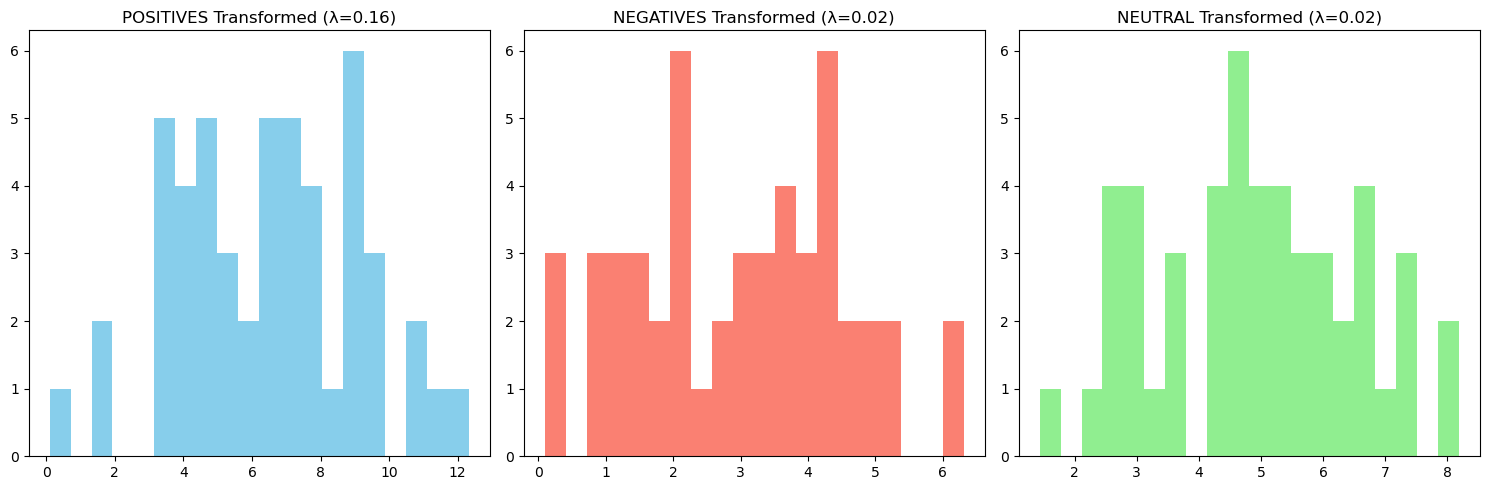

'/Users/reshmarajan/Desktop/youtube videos/HANDS-ON VIDEO/HANDS-ON_VIDEOS_TRANSFORMED_WITH_NA.xlsx'

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from matplotlib import pyplot as plt

# Load the Excel file
file_path = '/Users/reshmarajan/Desktop/youtube videos/HANDS-ON VIDEO/HANDS-ON_VIDEOS.xlsx'
data = pd.read_excel(file_path, sheet_name='Sheet1')

# Ensure columns have no zero or negative values by adding a small constant
positives = data['POSITIVES'] + 1.1
negatives = data['NEGATIVES'] + 1.1
neutral = data['NEUTRAL'] + 1.1

# Apply Box-Cox transformation where possible
positives_transformed, pos_lambda = boxcox(positives.dropna())
negatives_transformed, neg_lambda = boxcox(negatives.dropna())
neutral_transformed, neu_lambda = boxcox(neutral.dropna())

# Create a new DataFrame with the transformed columns
transformed_data = data.copy()
transformed_data['POS_TRANSFORM'] = np.nan
transformed_data['NEG_TRANSFORM'] = np.nan
transformed_data['NEU_TRANSFORM'] = np.nan

# Fill the new columns with the transformed data where available
transformed_data.loc[positives.dropna().index, 'POS_TRANSFORM'] = positives_transformed
transformed_data.loc[negatives.dropna().index, 'NEG_TRANSFORM'] = negatives_transformed
transformed_data.loc[neutral.dropna().index, 'NEU_TRANSFORM'] = neutral_transformed

# Save the transformed data to a new Excel file
output_file_path_with_na = '/Users/reshmarajan/Desktop/youtube videos/HANDS-ON VIDEO/HANDS-ON_VIDEOS_TRANSFORMED_WITH_NA.xlsx'
transformed_data.to_excel(output_file_path_with_na, index=False)

# Plot histograms of the transformed data
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(positives_transformed, bins=20, color='skyblue')
plt.title(f'POSITIVES Transformed (λ={pos_lambda:.2f})')

plt.subplot(1, 3, 2)
plt.hist(negatives_transformed, bins=20, color='salmon')
plt.title(f'NEGATIVES Transformed (λ={neg_lambda:.2f})')

plt.subplot(1, 3, 3)
plt.hist(neutral_transformed, bins=20, color='lightgreen')
plt.title(f'NEUTRAL Transformed (λ={neu_lambda:.2f})')

plt.tight_layout()
plt.show()

output_file_path_with_na
